In [6]:
import requests
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [5]:
!pip install statsmodels

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 33.3 MB/s eta 0:00:00 0:00:01


In [7]:
number_of_lags=20
bollinger_days=40

In [8]:
def calculate_rsi(prices, period=20):
    """Calculate Relative Strength Index (RSI)"""
    deltas = np.diff(prices)
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)
    
    avg_gain = np.convolve(gains, np.ones(period)/period, mode='valid')
    avg_loss = np.convolve(losses, np.ones(period)/period, mode='valid')
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return np.concatenate(([np.nan] * (len(prices) - len(rsi)), rsi))


In [9]:
def stochastic_oscillator(prices, period=20):
    """Calculate Stochastic Oscillator %K and %D"""
    high_n = np.array([np.max(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])
    low_n = np.array([np.min(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])
    
    k = 100 * (prices[period-1:] - low_n) / (high_n - low_n)
    d = np.convolve(k, np.ones(3)/3, mode='valid')

    k = np.concatenate(([np.nan] * (period-1), k))
    d = np.concatenate(([np.nan] * (period-1 + 2), d))  # Aligning with %K

    return k, d

In [10]:
def calculate_momentum(prices, period=10):
    """Calculate momentum as the difference between current price and price x days ago."""
    momentum = prices - np.roll(prices, period)
    momentum[:period] = np.nan  # Set first 'period' values to NaN
    return momentum

In [11]:
def weighted_moving_average(prices, period=20, step=1):
    """Calculate Weighted Moving Average (WMA) where recent points get higher weight."""
    weights = np.arange(1, period + 1, step=step)  # Assign weights (1, 2, 3, ..., period)
    wma = np.convolve(prices, weights / weights.sum(), mode='valid')
    
    # Align the result with original length by padding with NaN
    return np.concatenate(([np.nan] * (len(prices) - len(wma)), wma))

In [12]:
def bollinger_bands(prices, period=20, std_dev_factor=2):
    """Calculate Bollinger Bands."""
    sma = np.convolve(prices, np.ones(period)/period, mode='valid')  # Simple Moving Average
    rolling_std = np.array([np.std(prices[i-period+1:i+1]) for i in range(period-1, len(prices))])  # Rolling Std Dev

    upper_band = sma + std_dev_factor * rolling_std
    lower_band = sma - std_dev_factor * rolling_std

    # Align lengths with original price data by padding with NaN
    upper_band = np.concatenate(([np.nan] * (len(prices) - len(upper_band)), upper_band))
    lower_band = np.concatenate(([np.nan] * (len(prices) - len(lower_band)), lower_band))
    sma = np.concatenate(([np.nan] * (len(prices) - len(sma)), sma))

    return sma, upper_band, lower_band


In [13]:
def momentum(prices, window=10):
    """Calculate momentum as the sum of differences over a rolling window."""
    diffs = np.diff(prices)  # First-order differences
    momentum_values = np.convolve(diffs, np.ones(window), mode='valid')  # Sum over window

    # Align lengths by padding with NaN
    momentum_values = np.concatenate(([np.nan] * (len(prices) - len(momentum_values)), momentum_values))
    return momentum_values


In [15]:

def create_dataset(df):
    # stock = yf.Ticker(stock_symbol)
    # df = stock.history(period="1y")
    # df["Stock"] = stock_symbol
    scaler = MinMaxScaler(feature_range=(0,1))
    scaler.fit(df['Close'].to_numpy().reshape(-1,1))
    df['Close'] = scaler.transform(df['Close'].to_numpy().reshape(-1,1))

    # Compute indicators
    df['RSI'] = calculate_rsi(df['Close'].values, period=10)
    df['Stochastic_K'], df['Stochastic_D'] = stochastic_oscillator(df['Close'].values, period=50)
    df['Stochastic_difference'] = df['Stochastic_D'] - df['Stochastic_D'].shift(1)
    
    # Compute 20-day Moving Average
    df['Moving_Avg_10'] = df['Close'].rolling(window=10).mean()
    df['Moving_Avg_20'] = df['Close'].rolling(window=20).mean()
    df['Moving_Avg_30']=df['Close'].rolling(window=30).mean()
    df['Moving_Avg_50']=df['Close'].rolling(window=50).mean()
    df['Momentum'] = calculate_momentum(df['Close'].values, period=30)
    df['WMA_20'] = weighted_moving_average(df['Close'].values, period=40, step=5)
    df['SMA_20'], df['Upper_Band'], df['Lower_Band'] = bollinger_bands(df['Close'].values, period=40)
    df['Window_Momentum'] = momentum(df['Close'].values, window=10)

    for i in range(1, number_of_lags):
        df[f'Close_Lag{i}'] = df['Close'].shift(i)


    # Drop rows with NaN values
    df.dropna(inplace=True)

    # Plot the results
    plt.figure(figsize=(14,9))

    plt.subplot(3,1,1)
    plt.plot(df.index, df['Close'], label='Close Price', color='blue')
    # plt.plot(df.index, df['WMA_20'], label='Weighted MA (20 days)', color='purple')
    plt.plot(df.index, df['SMA_20'], label='SMA (20 days)', color='green')
    plt.plot(df.index, df['Upper_Band'], label='Upper Bollinger Band', color='red', linestyle='--')
    plt.plot(df.index, df['Lower_Band'], label='Lower Bollinger Band', color='blue', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_10'], label='10-day Moving Avg', color='red', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_20'], label='20-day Moving Avg', color='purple', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_30'], label='30-day Moving Avg', color='orange', linestyle='--')
    # plt.plot(df.index, df['Moving_Avg_50'], label='50-day Moving Avg', color='green', linestyle='--')
    plt.legend()

    plt.subplot(3,1,2)
    plt.scatter(df.index, df['Momentum'], label='Momentum', color='brown')
    plt.plot(df.index, df['Momentum'], label='Momentum', color='brown')
    plt.axhline(0, linestyle='--', color='gray')
    plt.legend()
    # plt.plot(df.index, df['RSI'], label='RSI', color='red')
    # plt.axhline(70, linestyle='--', color='gray')
    # plt.axhline(30, linestyle='--', color='gray')
    plt.legend()

    plt.subplot(3,1,3)
    # plt.plot(df.index, df['Stochastic_K'], label='%K', color='green')
    # plt.plot(df.index, df['Stochastic_D'], label='%D', color='orange')
    plt.scatter(df.index, df['Window_Momentum'], label='Momentum (10-day)', color='purple')
    
    plt.axhline(0, linestyle='--', color='gray')
    
    plt.legend()

    plt.tight_layout()
    plt.show()

    return df

In [23]:
# Define stock symbols
from sklearn.preprocessing import MinMaxScaler
stock_symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

# Fetch and combine stock data
dataframes = []
scalars=[]
for stock_symbol in stock_symbols:
    stock = yf.Ticker(stock_symbol)
    df = stock.history(period="1y")  # Fetch 1 year of historical data
    df["Stock"] = stock_symbol  # Add stock symbol column
    scaler= MinMaxScaler(feature_range=(0,1))
    scaler.fit_transform(df['Close'].to_numpy().reshape(-1,1))
    df['Close']=scaler.transform(df['Close'].to_numpy().reshape(-1,1))
    scalars.append(scaler)

    for i in range(1, 20):
      df[f'Close_Lag{i}'] = df['Close'].shift(i)

    # Drop rows with NaN values caused by shifting
    df.dropna(inplace=True)
    dataframes.append(df)

# Concatenate all stock data vertically
combined_data = pd.concat(dataframes).reset_index()




In [24]:
# One-hot encode the 'Stock' column
one_hot_encoded = pd.get_dummies(combined_data, columns=["Stock"])


one_hot_encoded.describe()
one_hot_encoded.info()
one_hot_encoded.to_csv('historical_data.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          1165 non-null   datetime64[ns, America/New_York]
 1   Open          1165 non-null   float64                         
 2   High          1165 non-null   float64                         
 3   Low           1165 non-null   float64                         
 4   Close         1165 non-null   float64                         
 5   Volume        1165 non-null   int64                           
 6   Dividends     1165 non-null   float64                         
 7   Stock Splits  1165 non-null   float64                         
 8   Close_Lag1    1165 non-null   float64                         
 9   Close_Lag2    1165 non-null   float64                         
 10  Close_Lag3    1165 non-null   float64                         
 11  Clos

In [25]:
print(one_hot_encoded.describe())

              Open         High          Low        Close        Volume  \
count  1165.000000  1165.000000  1165.000000  1165.000000  1.165000e+03   
mean    248.835499   251.786745   245.791723     0.453879  4.686958e+07   
std     100.322675   101.255725    99.122049     0.246543  3.425817e+07   
min     131.403656   132.758744   130.198020     0.000000  7.164500e+06   
25%     176.563087   178.789993   174.300003     0.265885  2.277560e+07   
50%     201.020004   205.600006   198.779999     0.436786  3.654690e+07   
75%     263.299988   269.489990   257.630005     0.644255  6.041240e+07   
max     475.899994   488.540009   462.698189     1.000000  3.186799e+08   

         Dividends  Stock Splits   Close_Lag1   Close_Lag2   Close_Lag3  ...  \
count  1165.000000        1165.0  1165.000000  1165.000000  1165.000000  ...   
mean      0.003159           0.0     0.451170     0.448453     0.445815  ...   
std       0.042574           0.0     0.245719     0.244761     0.244347  ...   
min 

In [4]:
!pip install numpy matplotlib pandas scikit-learn

  Using cached pandas-2.2.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached contourpy-1.3.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pillow-11.1.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 6.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 6.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2025-03-24 15:37:40 - LayerLogger - INFO - Layer initialized successfully
2025-03-24 15:37:40 - LayerLogger - INFO - Layer initialized successfully
2025-03-24 15:37:40 - LayerLogger - INFO - Layer initialized successfully


Epoch 0, Loss: 0.030478, metric: 0.152254
Epoch 500, Loss: 0.000869, metric: 0.020990


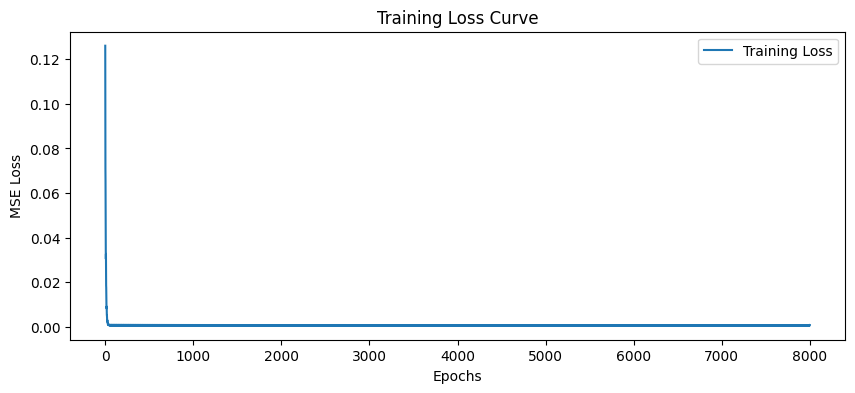

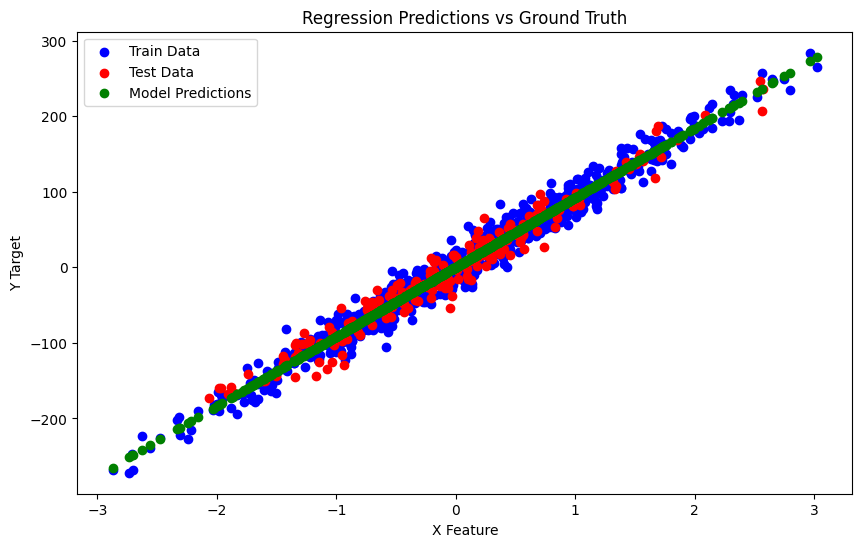

2025-03-24 15:37:42 - LayerLogger - INFO - Layer initialized successfully
2025-03-24 15:37:42 - LayerLogger - INFO - Layer initialized successfully
2025-03-24 15:37:42 - LayerLogger - INFO - Layer initialized successfully


Epoch 0, Loss: 0.837581, metric: 0.833152
Epoch 500, Loss: 0.000885, metric: 0.021346


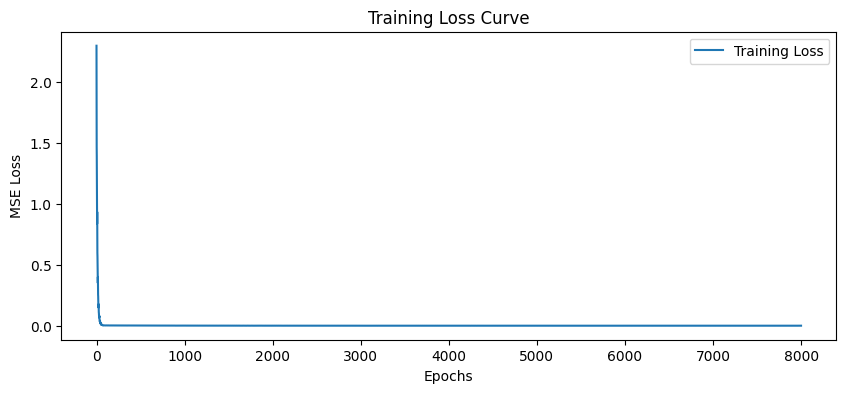

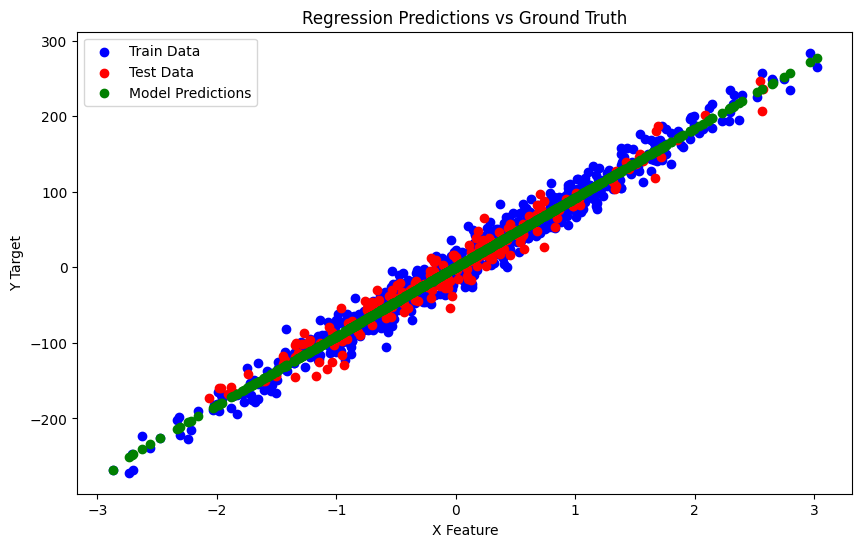

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from ann_model import *
# Generate synthetic regression data
X, Y = make_regression(n_samples=1000, n_features=1, noise=15, random_state=420)
Y = Y.reshape(-1, 1)  # Reshape to match neural network output shape

# Normalize data
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)

# ANN model with a simple architecture
model = ANNModel()
model.add_layer(number_of_neurons=64, input_shape=X_train.shape[1], activation_function="relu")
model.add_layer(number_of_neurons=32, activation_function="relu")
model.add_layer(number_of_neurons=1, activation_function="linear")
model.compile(loss="mse", metric="mae", learning_rate=0.001, alpha=0.01, batch_size=100)

# Train the model
losses = model.train(X_train, Y_train)

# Predictions on train and test sets
Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

# Rescale predictions back to the original scale
Y_pred_train_rescaled = scaler_Y.inverse_transform(Y_pred_train)
Y_pred_test_rescaled = scaler_Y.inverse_transform(Y_pred_test)
Y_train_rescaled = scaler_Y.inverse_transform(Y_train)
Y_test_rescaled = scaler_Y.inverse_transform(Y_test)

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

# Plot Predictions vs Ground Truth
plt.figure(figsize=(10, 6))
plt.scatter(scaler_X.inverse_transform(X_train), Y_train_rescaled, label="Train Data", color="blue")
plt.scatter(scaler_X.inverse_transform(X_test), Y_test_rescaled, label="Test Data", color="red")
plt.scatter(scaler_X.inverse_transform(X_train), Y_pred_train_rescaled, label="Model Predictions", color="green")
plt.xlabel("X Feature")
plt.ylabel("Y Target")
plt.title("Regression Predictions vs Ground Truth")
plt.legend()
plt.show()

In [17]:
from data_scraper import StockDataScraper
from custom_logger import CustomLogger
import datetime
import pandas as pd
data=pd.read_csv('MSFT Historical Data (2).csv')
data.head()
# rename the column open to close
data.rename(columns={'Open': 'Close'}, inplace=True)
data.head()

,Date,Price,Close,High,Low,Vol.,Change %
0,25-03-2025,395.16,393.92,396.36,392.64,15.77M,0.53%
1,24-03-2025,393.08,395.40,395.40,389.81,21.00M,0.47%
2,21-03-2025,391.26,383.21,391.74,382.80,39.68M,1.14%
3,20-03-2025,386.84,385.73,391.79,383.28,18.47M,-0.25%
4,19-03-2025,387.82,385.52,389.68,384.00,19.19M,1.12%


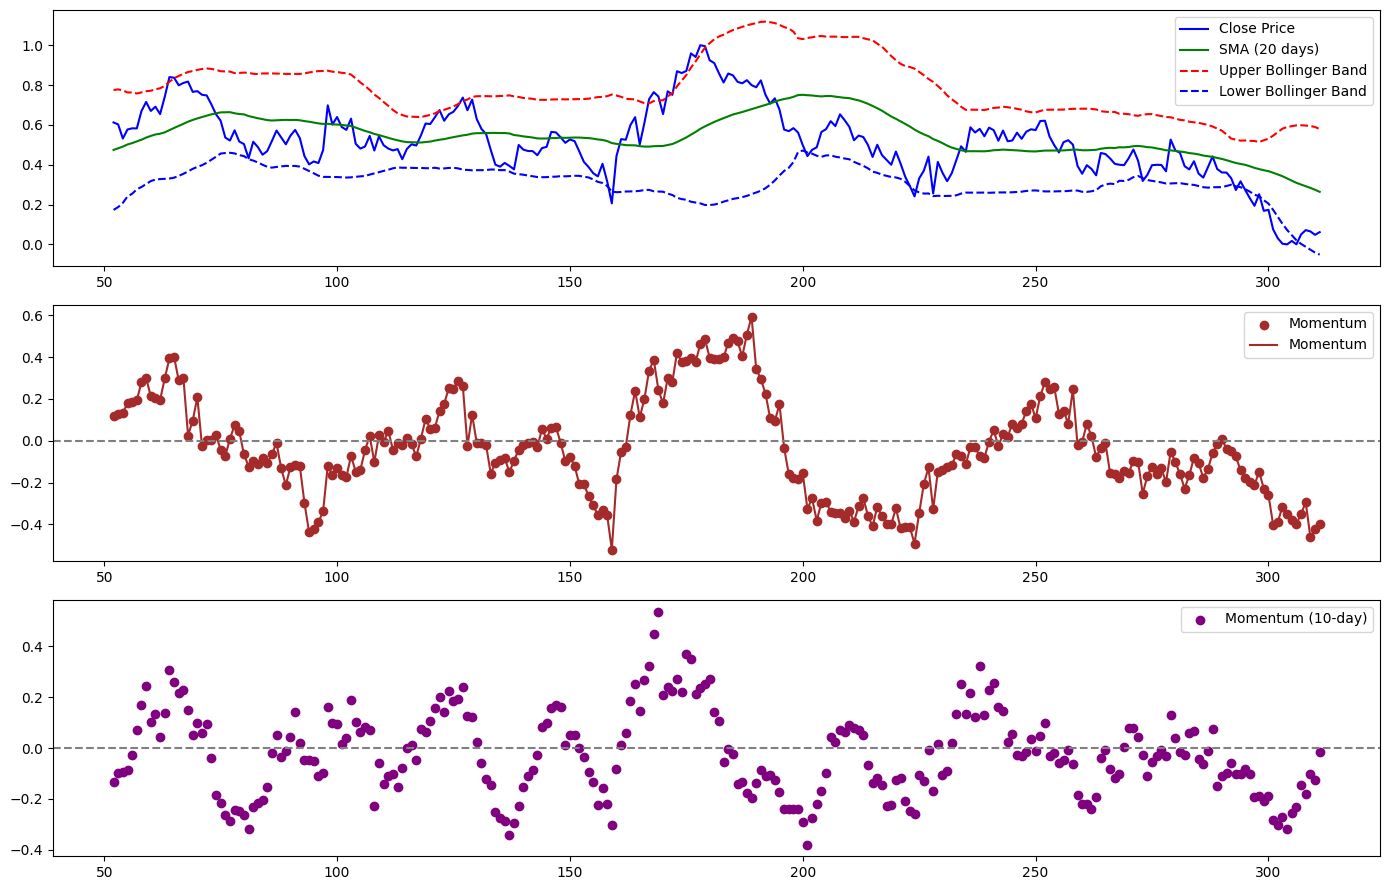

,Date,Price,Close,High,Low,Vol.,Change %,RSI,Stochastic_K,Stochastic_D,...,Close_Lag10,Close_Lag11,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19
52,07-01-2025,422.37,0.612364,430.65,420.80,18.14M,-1.28%,37.164297,73.866155,68.986064,...,0.744976,0.777211,0.561461,0.669489,0.792819,0.508008,0.510150,0.434867,0.445884,0.442518
53,06-01-2025,427.85,0.602163,434.32,425.48,20.57M,1.06%,39.872881,72.388831,70.645590,...,0.699684,0.744976,0.777211,0.561461,0.669489,0.792819,0.508008,0.510150,0.434867,0.445884
54,03-01-2025,423.35,0.531572,424.03,419.54,16.66M,1.14%,40.248075,62.165756,69.473581,...,0.624605,0.699684,0.744976,0.777211,0.561461,0.669489,0.792819,0.508008,0.510150,0.434867
55,02-01-2025,418.58,0.576966,426.07,414.85,16.90M,-0.69%,40.967674,68.739843,67.764810,...,0.664184,0.624605,0.699684,0.744976,0.777211,0.561461,0.669489,0.792819,0.508008,0.510150
56,31-12-2024,421.50,0.582781,426.73,420.66,13.25M,-0.78%,46.942615,69.581918,66.829172,...,0.609303,0.664184,0.624605,0.699684,0.744976,0.777211,0.561461,0.669489,0.792819,0.508008


In [18]:
data=create_dataset(data)
data.head()


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from ann_model import *  # Assuming ann_model contains the ANN implementation

# Selecting features and target variable
features = ["High", "Low", "RSI", "Stochastic_K", "Stochastic_D",
            "Close_Lag10", "Close_Lag11", "Close_Lag12", "Close_Lag13", "Close_Lag14", 
            "Close_Lag15", "Close_Lag16", "Close_Lag17", "Close_Lag18", "Close_Lag19"]
X = data[features].values
Y = data["Close"].values.reshape(-1, 1)



In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 52 to 311
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   260 non-null    object 
 1   Price                  260 non-null    float64
 2   Close                  260 non-null    float64
 3   High                   260 non-null    float64
 4   Low                    260 non-null    float64
 5   Vol.                   260 non-null    object 
 6   Change %               260 non-null    object 
 7   RSI                    260 non-null    float64
 8   Stochastic_K           260 non-null    float64
 9   Stochastic_D           260 non-null    float64
 10  Stochastic_difference  260 non-null    float64
 11  Moving_Avg_10          260 non-null    float64
 12  Moving_Avg_20          260 non-null    float64
 13  Moving_Avg_30          260 non-null    float64
 14  Moving_Avg_50          260 non-null    float64
 15  Momentum  

In [26]:
data.describe()

,Price,Close,High,Low,RSI,Stochastic_K,Stochastic_D,Stochastic_difference,Moving_Avg_10,Moving_Avg_20,...,Close_Lag10,Close_Lag11,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,419.657308,0.518213,422.985231,416.079346,46.109891,43.356166,43.569297,-0.196623,0.526922,0.537137,...,0.539750,0.542449,0.543940,0.545867,0.547947,0.549155,0.550225,0.550846,0.551343,0.551994
std,18.354415,0.186675,18.352116,18.186690,18.517307,31.056519,30.009469,6.352227,0.162413,0.135848,...,0.160758,0.158812,0.157148,0.155591,0.155260,0.153709,0.152457,0.151651,0.151092,0.150251
min,367.750000,0.000000,372.060000,366.500000,3.357472,0.000000,0.000000,-17.711503,0.034867,0.131985,...,0.075487,0.168520,0.168520,0.193920,0.193920,0.206059,0.206059,0.206059,0.206059,0.206059
25%,409.290000,0.408829,413.037500,406.077500,32.236478,17.049998,17.098296,-3.777464,0.423990,0.461990,...,0.432189,0.433107,0.437698,0.440299,0.441370,0.442824,0.443308,0.443308,0.443793,0.443793
50%,418.525000,0.515862,422.550000,415.405000,45.905088,40.544875,40.298676,-0.385458,0.518280,0.526283,...,0.522187,0.522850,0.524278,0.525859,0.526420,0.526420,0.526420,0.526420,0.526420,0.526420
75%,429.170000,0.618969,432.215000,425.717500,60.713522,68.756563,69.778330,3.841289,0.589570,0.605465,...,0.621570,0.623763,0.623763,0.625625,0.629348,0.629348,0.629348,0.629348,0.629348,0.629348
max,467.560000,1.000000,468.350000,464.460000,84.123771,100.000000,99.528568,21.443539,0.919004,0.866123,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
# Normalize data
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)



2025-03-26 11:37:28 - LayerLogger - INFO - Layer initialized successfully
2025-03-26 11:37:28 - LayerLogger - INFO - Layer initialized successfully
2025-03-26 11:37:28 - LayerLogger - INFO - Layer initialized successfully
2025-03-26 11:37:28 - LayerLogger - INFO - Layer initialized successfully


Epoch 0, Loss: 0.347925, metric: 0.513413
Epoch 500, Loss: 0.001309, metric: 0.047123


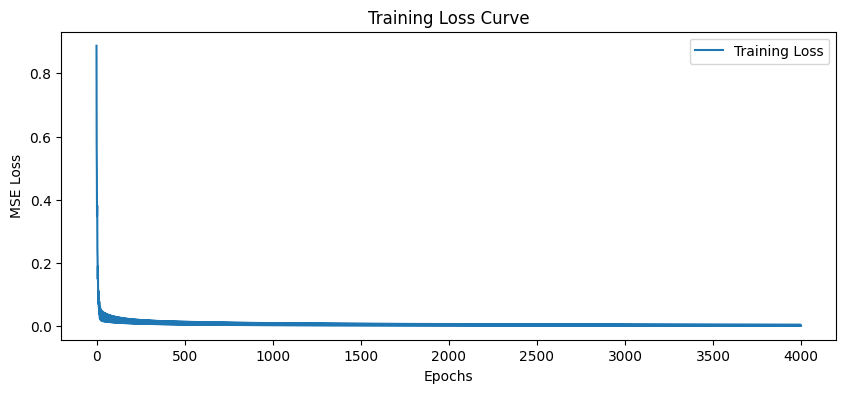

Mean Squared Error: 0.003616945757389362


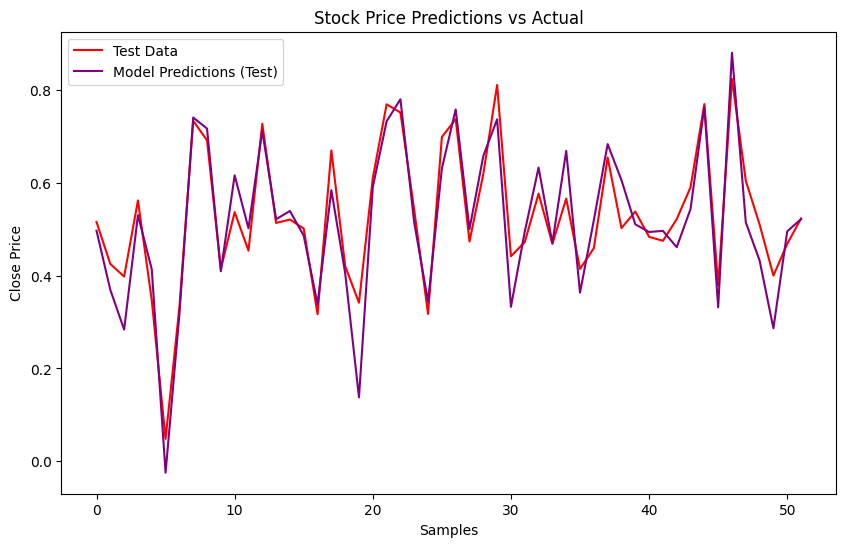

In [32]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)

# Define ANN model
model = ANNModel()
model.add_layer(number_of_neurons=128, input_shape=X_train.shape[1], activation_function="relu")
model.add_layer(number_of_neurons=64, activation_function="relu")
model.add_layer(number_of_neurons=32, activation_function="relu")
model.add_layer(number_of_neurons=1, activation_function="linear")
model.compile(loss="mse", metric="mae", learning_rate=0.001, alpha=0.01, batch_size=64)

# Train the model
losses = model.train(X_train, Y_train)

# Predictions
Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

# Rescale predictions back to the original scale
Y_pred_train_rescaled = scaler_Y.inverse_transform(Y_pred_train)
Y_pred_test_rescaled = scaler_Y.inverse_transform(Y_pred_test)
Y_train_rescaled = scaler_Y.inverse_transform(Y_train)
Y_test_rescaled = scaler_Y.inverse_transform(Y_test)

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

# get the testing loss using y_test and y_pred_test
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test_rescaled, Y_pred_test_rescaled)
print(f"Mean Squared Error: {mse}")

# Plot Predictions vs Ground Truth
plt.figure(figsize=(10, 6))
# plt.plot(Y_train_rescaled, label="Train Data", color="blue")
plt.plot(Y_test_rescaled, label="Test Data", color="red")
# plt.plot(Y_pred_train_rescaled, label="Model Predictions (Train)", color="green")
plt.plot(Y_pred_test_rescaled, label="Model Predictions (Test)", color="purple")

plt.xlabel("Samples")
plt.ylabel("Close Price")
plt.title("Stock Price Predictions vs Actual")
plt.legend()
plt.show()